In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from pathlib import Path
import pandas as pd

path = Path.cwd() / 'car' / 'car.data'
print(path)

df = pd.read_csv(path, header=None)
print(df.head())

c:\Users\ASUS\Desktop\code\ML\knn classifier\car\car.data
       0      1  2  3      4     5      6
0  vhigh  vhigh  2  2  small   low  unacc
1  vhigh  vhigh  2  2  small   med  unacc
2  vhigh  vhigh  2  2  small  high  unacc
3  vhigh  vhigh  2  2    med   low  unacc
4  vhigh  vhigh  2  2    med   med  unacc


In [3]:
df = pd.read_csv('car/car.data', header=None)
type(df)

pandas.DataFrame

In [4]:
df.sample(4)
df.shape

(1728, 7)

In [5]:
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df.columns = col_names
df.sample(3)
print(df['buying'].unique())
print(df['maint'].unique())
print(df['doors'].unique())

<StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
<StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
<StringArray>
['2', '3', '4', '5more']
Length: 4, dtype: str


In [6]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   class     1728 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB


In [8]:
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
for col in col_names:    
    print(df[col].value_counts())   

buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
persons
2       576
4       576
more    576
Name: count, dtype: int64
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
safety
low     576
med     576
high    576
Name: count, dtype: int64
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [9]:
df['safety'].value_counts()

safety
low     576
med     576
high    576
Name: count, dtype: int64

In [10]:
df['safety'].value_counts()

safety
low     576
med     576
high    576
Name: count, dtype: int64

In [11]:
df['class'].value_counts()
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
X = df.drop(['class'], axis=1)
y = df['class']

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [15]:
X_train.shape, X_test.shape

((1382, 6), (346, 6))

In [16]:
X_train.head()

,buying,maint,doors,persons,lug_boot,safety
107,vhigh,vhigh,5more,more,big,high
901,med,vhigh,3,4,small,med
1709,low,low,5more,2,big,high
706,high,med,4,2,med,med
678,high,med,3,2,med,low


In [17]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

In [18]:
category_orders=[
    ['low','med','high','vhigh'],
    ['low','med','high','vhigh'],
    ['2', '3', '4', '5more'],        
    ['2', '4', 'more'],                 
    ['small', 'med', 'big'],            
    ['low', 'med', 'high']             
]
encoder = OrdinalEncoder(categories=category_orders,dtype=int)
X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)


In [19]:
le=LabelEncoder()
le.fit(y_train)
y_train=le.transform(y_train)
y_test=le.transform(y_test) 

In [20]:
y_train

array([2, 2, 2, ..., 0, 2, 0], shape=(1382,))

In [21]:
le.classes_

array(['acc', 'good', 'unacc', 'vgood'], dtype=object)

In [22]:
X_train_encoded = pd.DataFrame(X_train_encoded, columns=X_train.columns)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=X_train.columns)
X_train_encoded.head()

,buying,maint,doors,persons,lug_boot,safety
0,3,3,3,2,2,2
1,1,3,1,1,0,1
2,0,0,3,0,2,2
3,2,1,2,0,1,1
4,2,1,1,0,1,0


In [23]:
X_test_encoded.head()

,buying,maint,doors,persons,lug_boot,safety
0,2,2,2,0,1,2
1,1,0,0,1,1,1
2,2,2,3,0,2,1
3,0,2,3,1,1,1
4,1,0,2,2,1,0


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

In [25]:
clf_en=DecisionTreeClassifier(criterion='gini' , random_state=42)
clf_en.fit(X_train_encoded, y_train)
y_pred_en=clf_en.predict(X_test_encoded)
print('Model Encoded score with criterion','entropy :{0:0.4f}'. format(accuracy_score(y_test, y_pred_en)))

Model Encoded score with criterion entropy :0.9653


In [26]:

clf_gini = DecisionTreeClassifier(criterion='gini', random_state=0)
clf_gini.fit(X_train_encoded, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [27]:
y_pred_gini = clf_gini.predict(X_test_encoded)

In [28]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_gini)))

Model accuracy score with criterion gini index: 0.9624


In [29]:
y_pred_train_gini = clf_gini.predict(X_train_encoded)

y_pred_train_gini

array([2, 2, 2, ..., 0, 2, 0], shape=(1382,))

In [30]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_gini)))

Training-set accuracy score: 1.0000


In [31]:
print('training set score {:4.4f}'.format(clf_gini.score(X_train_encoded, y_train)))

training set score 1.0000


In [32]:
print('test set score {:4.4f}'.format(clf_gini.score(X_test_encoded, y_test)))

test set score 0.9624


In [33]:
from sklearn.tree import plot_tree

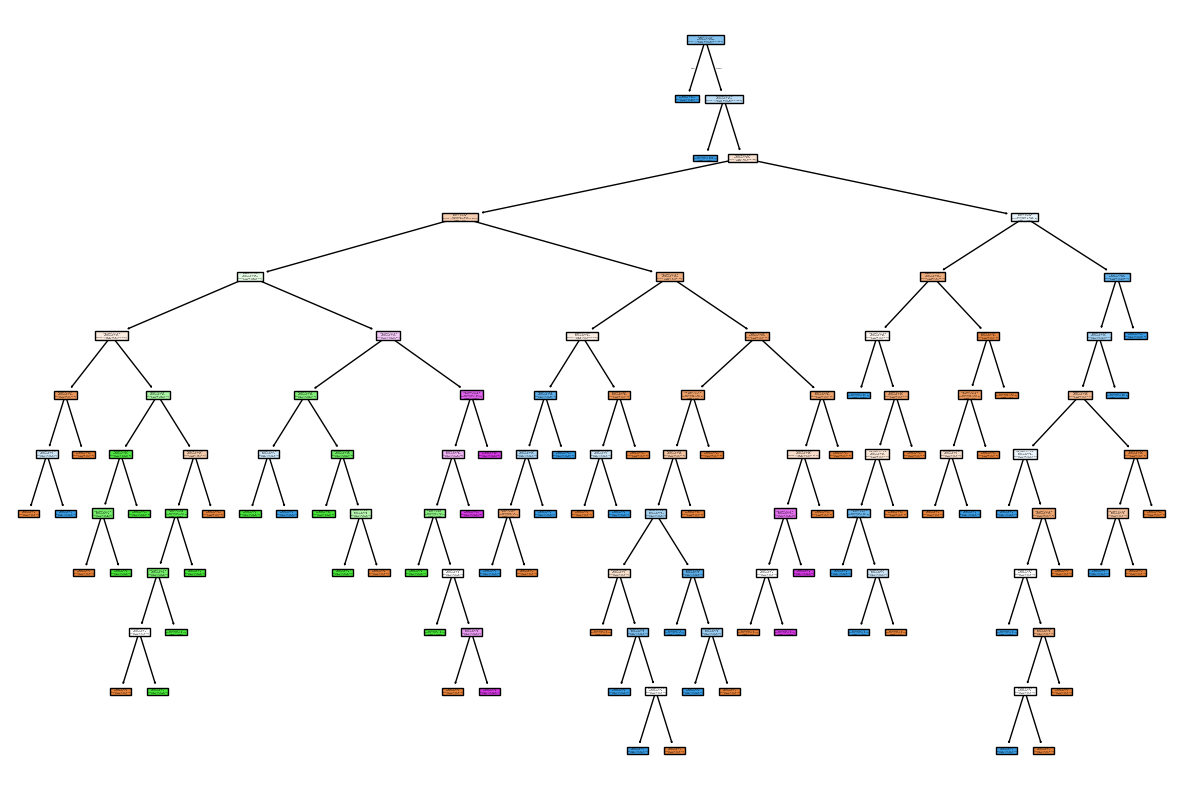

In [34]:
plt.figure(figsize=(15,10))
plot_tree(clf_gini,feature_names=X.columns,class_names=le.classes_,filled=True)
plt.show()

In [38]:
clf_gini_pr = DecisionTreeClassifier(criterion='gini', random_state=42 , max_depth=3)
clf_gini_pr.fit (X_train_encoded, y_train)
y_pred_en_pr=clf_gini_pr.predict(X_train_encoded)
y_pred_test_pr = clf_gini_pr.predict(X_test_encoded)
print('Model accuracy score with criterion gini: {0:0.4f}'.format(accuracy_score(y_test, y_pred_test_pr)))

Model accuracy score with criterion gini: 0.8121
